# 10 — Quadratic Equations

**Equations and Inequalities ▸ 2.** Last time the graph was a *straight line* — the rate
never changed. Today the graph finally **bends**. A **quadratic** has an $x^2$ term, and
its graph is a **parabola**: a smooth U-shaped curve.

Mental picture: throw a ball. Its height over time traces a parabola — up, slow at the
top, then down. The single most useful skill of the topic is **solving** $ax^2+bx+c=0$:
finding where the parabola crosses the $x$-axis.

**Why it matters for AI.** A parabola is the simplest **convex** ("bowl") shape, and the
loss functions we minimise when *training* models are bowls like this. Finding the
**vertex** (the bottom of the bowl) is exactly what **gradient descent** does. The
least-squares error from last session is a quadratic in the weights — its minimum is the
best fit. So "solve / minimise a quadratic" is the toy version of "train a model".

## Quick recall (spaced repetition)
From session 9 (Linear Functions). Solutions at the **end of §1**.

1. Find the slope of the line through $(-1, 4)$ and $(3, -4)$.
2. A line is **perpendicular** to $y = \tfrac12 x + 7$. What is its slope, and why?
3. **(older weak spot)** Simplify $\sqrt{(2-x)^2}$ for any real $x$.

## What we cover today
1. What a **quadratic equation** is; the parabola; **roots/zeros**.
2. Solving by **factoring** (Zero Product Property — callback to topic 5).
3. The **square-root method** for $x^2 = k$.
4. **Completing the square** (the engine), and from it the **quadratic formula** (proved).
5. The **discriminant** $b^2-4ac$: how many real roots, and which kind (proved).
6. **Vieta's formulas**: sum and product of the roots (proved).
7. **Vertex form** and the vertex $x=-\tfrac{b}{2a}$ (proved) — the bottom of the bowl.
8. Python: `numpy`/`sympy` solving, plotting the parabola, and a tiny **gradient-descent**
   that rolls down to the vertex (the AI hook).

## 1. Definitions

> **Definition (quadratic equation).** A **quadratic equation** in one variable $x$ is an
> equation that can be written in the **standard form**
> $$ a x^2 + b x + c = 0, \qquad a \ne 0, $$
> where $a, b, c$ are real constants. The condition $a\ne 0$ is what makes it quadratic
> (degree $2$); if $a=0$ it would be linear.

> **Definition (parabola, root).** The graph of $y = ax^2+bx+c$ is a **parabola**. It
> opens **up** if $a>0$ (a bowl) and **down** if $a<0$ (a dome). A **root** (or **zero**,
> or **solution**) is a value of $x$ with $ax^2+bx+c=0$ — a point where the parabola meets
> the $x$-axis.

The word "quadratic" comes from *quadratus*, Latin for "square" — because of the $x^2$
("x squared"). A quadratic has **at most two** real roots (a line and a parabola cross at
most twice; here the line is the $x$-axis). We will see *exactly* how many using the
discriminant.

### Solutions to the recall warm-ups

1. $m = \dfrac{-4 - 4}{3 - (-1)} = \dfrac{-8}{4} = -2.$
2. Perpendicular slopes are **negative reciprocals** (Theorem 6, session 9): the slope is
   $-\dfrac{1}{1/2} = -2$, because $m_1 m_2 = -1$.
3. $\sqrt{(2-x)^2} = |2-x| = |x-2|$. The square root returns the non-negative root, so we
   need absolute value — never just $2-x$.

## 2. Method 1 — solving by factoring

This rests on a fact we **proved** in topic 5.

> **Zero Product Property (recall, topic 5).** For real numbers, $PQ = 0$ **iff** $P=0$
> or $Q=0$. (Proof idea: $\mathbb{R}$ is a field with no zero divisors — if $P\ne0$ it has
> an inverse, multiply $PQ=0$ by $P^{-1}$ to force $Q=0$.)

**Recipe.** Put the equation in standard form $=0$, factor the left side, then set each
factor to $0$.

**Example.** Solve $x^2 - 5x + 6 = 0$.
$$ x^2 - 5x + 6 = (x-2)(x-3) = 0 \;\Longrightarrow\; x-2=0 \text{ or } x-3=0
   \;\Longrightarrow\; x = 2 \text{ or } x = 3. $$
(We found $-2,-3$ by the "add to $-5$, multiply to $+6$" trick from topic 5.)

**Warning — never divide by a variable.** To solve $x^2 = 5x$, do **not** cancel $x$ (you
would lose the root $x=0$). Instead move everything to one side: $x^2-5x=0$, factor
$x(x-5)=0$, giving $x=0$ or $x=5$.

## 3. Method 2 — the square-root method

> **Theorem 1 (square-root method).** For $k \in \mathbb{R}$, the equation $x^2 = k$ has:
> - two real solutions $x = \pm\sqrt{k}$ if $k>0$;
> - one solution $x = 0$ if $k=0$;
> - **no real** solutions if $k<0$.

**Proof.** If $k<0$: a square $x^2$ is always $\ge 0$ (topic 2 order rule), so it can never
equal a negative $k$. If $k=0$: $x^2=0 \Rightarrow x=0$ (a field has no zero divisors). If
$k>0$: by topic 8 (existence of the principal root) $\sqrt k$ exists, and
$$ x^2 = k \iff x^2 - k = 0 \iff (x-\sqrt k)(x+\sqrt k)=0 \iff x = \pm\sqrt k, $$
using the difference-of-squares factoring (topic 4) and the Zero Product Property. $\;\blacksquare$

**Example.** $(x-3)^2 = 16 \Rightarrow x-3 = \pm 4 \Rightarrow x = 7$ or $x=-1$. This
"take the $\pm$ square root" move is the key step inside completing the square, next.

## 4. Method 3 — completing the square, and the quadratic formula

**Idea of completing the square.** We turn $x^2 + px$ into a *perfect square* by adding
the right constant. Recall $(x + \tfrac{p}{2})^2 = x^2 + p x + \tfrac{p^2}{4}$. So
$$ x^2 + p x = \Bigl(x + \tfrac{p}{2}\Bigr)^2 - \frac{p^2}{4}. $$
We add and subtract $(\tfrac{p}{2})^2$ — "half the middle coefficient, squared".

**Worked number example.** Solve $x^2 + 6x + 5 = 0$ by completing the square.
$$ x^2+6x = (x+3)^2 - 9 \;\Rightarrow\; (x+3)^2 - 9 + 5 = 0 \;\Rightarrow\; (x+3)^2 = 4
   \;\Rightarrow\; x+3 = \pm 2 \;\Rightarrow\; x = -1 \text{ or } x=-5. $$

Now we run the *same* steps on the general equation to get a formula once and for all.

> **Theorem 2 (the Quadratic Formula).** Every quadratic equation
> $ax^2+bx+c=0$ with $a\ne 0$ has solutions
> $$ \boxed{\,x = \frac{-b \pm \sqrt{\,b^2 - 4ac\,}}{2a}\,} $$
> (real when $b^2-4ac \ge 0$).

**Proof (complete the square on the general equation).**

Start from $ax^2+bx+c=0$. Since $a\ne0$, divide by $a$:
$$ x^2 + \frac{b}{a}x + \frac{c}{a} = 0
   \;\Longrightarrow\; x^2 + \frac{b}{a}x = -\frac{c}{a}. $$
Here the "middle coefficient" is $p=\dfrac{b}{a}$, so half of it squared is
$\left(\dfrac{b}{2a}\right)^2 = \dfrac{b^2}{4a^2}$. Add it to **both** sides:
$$ x^2 + \frac{b}{a}x + \frac{b^2}{4a^2} = -\frac{c}{a} + \frac{b^2}{4a^2}. $$
The left side is now a perfect square; combine the right side over the common denominator
$4a^2$:
$$ \left(x + \frac{b}{2a}\right)^2 = \frac{b^2 - 4ac}{4a^2}. $$
Apply the square-root method (Theorem 1). Note $\sqrt{4a^2} = 2|a|$, and the $\pm$ absorbs
the sign of $a$, so we may write the denominator as $2a$:
$$ x + \frac{b}{2a} = \frac{\pm\sqrt{b^2-4ac}}{2a}. $$
Finally subtract $\dfrac{b}{2a}$:
$$ x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}. \qquad\blacksquare $$

This one formula solves **every** quadratic — even the ones that do not factor with nice
integers.

## 5. The discriminant — counting the roots before you solve

The quantity under the root sign decides everything.

> **Definition (discriminant).** The **discriminant** of $ax^2+bx+c$ is
> $$ \Delta = b^2 - 4ac. $$

> **Theorem 3 (discriminant test).** For a real quadratic $ax^2+bx+c=0$, $a\ne0$:
> - $\Delta > 0$ ⇒ **two distinct real** roots;
> - $\Delta = 0$ ⇒ **one repeated real** root (a "double root"), $x=-\tfrac{b}{2a}$;
> - $\Delta < 0$ ⇒ **no real** roots (two complex ones — next topic).

**Proof.** The roots are $x = \dfrac{-b\pm\sqrt{\Delta}}{2a}$ (Theorem 2).
- If $\Delta>0$: $\sqrt\Delta$ is a positive real, and $+\sqrt\Delta \ne -\sqrt\Delta$, so
  the two values of $x$ are different — two real roots.
- If $\Delta=0$: $\sqrt\Delta=0$, so both signs give the same $x=\dfrac{-b}{2a}$ — one
  repeated root.
- If $\Delta<0$: $\sqrt\Delta$ is not a real number (Theorem 1: no real square root of a
  negative), so there is no real solution. $\;\blacksquare$

Geometrically: $\Delta>0$ the parabola cuts the $x$-axis twice, $\Delta=0$ it just touches
(tangent at the vertex), $\Delta<0$ it floats entirely above or below the axis.

## 6. Vieta's formulas — the roots talk to the coefficients

> **Theorem 4 (Vieta's formulas).** If $r_1, r_2$ are the roots of $ax^2+bx+c=0$
> ($a\ne0$), then
> $$ r_1 + r_2 = -\frac{b}{a}, \qquad r_1 r_2 = \frac{c}{a}. $$

**Proof.** Dividing by $a$, the equation is $x^2 + \tfrac{b}{a}x + \tfrac{c}{a}=0$. Since
$r_1,r_2$ are its roots, it factors as
$$ x^2 + \tfrac{b}{a}x + \tfrac{c}{a} = (x-r_1)(x-r_2) = x^2 - (r_1+r_2)x + r_1 r_2. $$
Two polynomials are equal exactly when their coefficients match (topic 4). Matching the
$x$-coefficient: $-(r_1+r_2)=\tfrac{b}{a}$, so $r_1+r_2=-\tfrac{b}{a}$. Matching the
constant: $r_1 r_2 = \tfrac{c}{a}$. $\;\blacksquare$

*(Alternative one-line check: add and multiply $\dfrac{-b\pm\sqrt\Delta}{2a}$ directly —
the $\pm\sqrt\Delta$ cancels in the sum and is a difference of squares in the product.)*

**Use it.** Vieta lets you check answers fast: for $x^2-5x+6$, the roots $2,3$ satisfy
$2+3=5=-\tfrac{-5}{1}$ and $2\cdot3=6=\tfrac{6}{1}$. ✓

## 7. Vertex form — the bottom of the bowl

Completing the square on $y=ax^2+bx+c$ (not set to zero) reveals the **vertex**.

> **Theorem 5 (vertex form & location).** Every quadratic can be written as
> $$ y = a\,(x - h)^2 + k, \qquad\text{with}\qquad h = -\frac{b}{2a},\quad k = c - \frac{b^2}{4a}. $$
> The point $(h,k)$ is the **vertex**: the lowest point if $a>0$, the highest if $a<0$.
> The vertical line $x=h$ is the **axis of symmetry**.

**Proof.** Factor $a$ out of the first two terms and complete the square:
$$ y = a\Bigl(x^2 + \tfrac{b}{a}x\Bigr) + c
     = a\Bigl[(x+\tfrac{b}{2a})^2 - \tfrac{b^2}{4a^2}\Bigr] + c
     = a\,(x+\tfrac{b}{2a})^2 + \Bigl(c - \tfrac{b^2}{4a}\Bigr). $$
So $h=-\tfrac{b}{2a}$ and $k=c-\tfrac{b^2}{4a}$. Now why $(h,k)$ is the extreme point: the
square $(x-h)^2 \ge 0$ and equals $0$ only at $x=h$.
- If $a>0$: $a(x-h)^2 \ge 0$, so $y \ge k$, with equality only at $x=h$ — a **minimum**.
- If $a<0$: $a(x-h)^2 \le 0$, so $y \le k$ — a **maximum**.

Symmetry: replacing $x-h$ by $-(x-h)$ leaves $(x-h)^2$ unchanged, so the parabola is a
mirror image across $x=h$. $\;\blacksquare$

**AI hook.** "Find $x=-\tfrac{b}{2a}$ that minimises $y$" is the simplest optimisation
problem there is. Training a model is the same task on a far bigger bowl — and gradient
descent is how we roll to the bottom when we can't read off the vertex by hand. We do a
1-D version in code below.

## 8. Worked examples (all three methods + checks)

**Example A — quadratic formula.** Solve $2x^2 + 3x - 2 = 0$.
$$ \Delta = 3^2 - 4(2)(-2) = 9 + 16 = 25 > 0 \;(\text{two real roots}). $$
$$ x = \frac{-3 \pm \sqrt{25}}{2\cdot 2} = \frac{-3 \pm 5}{4}
   \;\Rightarrow\; x = \tfrac12 \text{ or } x = -2. $$
Vieta check: sum $= -\tfrac32 = -\tfrac{b}{a}$ ✓, product $= -1 = \tfrac{c}{a}$ ✓.

**Example B — repeated root ($\Delta=0$).** $x^2 - 6x + 9 = 0 \Rightarrow (x-3)^2=0
\Rightarrow x=3$ (double). $\Delta = 36-36 = 0$ ✓.

**Example C — no real roots ($\Delta<0$).** $x^2 + x + 1 = 0$: $\Delta = 1-4 = -3 < 0$, so
no real solution (the parabola floats above the axis). We solve this kind in the **next**
topic (complex numbers).

**Example D — vertex / optimisation.** For $y = x^2 - 4x + 7$: $h = -\tfrac{-4}{2}=2$,
$k = 7 - \tfrac{16}{4} = 3$. Vertex $(2,3)$, opens up ⇒ minimum value $3$ at $x=2$.

Let's verify with Python.

In [1]:
# Setup: numpy (numbers), sympy (exact algebra), matplotlib (plots).
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols('x')

# Example A solved exactly with sympy.solve.
solA = sp.solve(2*x**2 + 3*x - 2, x)        # solves 2x^2+3x-2 = 0 for x
print("Example A roots:", solA)              # [-2, 1/2]

# numpy.roots takes the coefficient list [a, b, c] and returns the roots numerically.
print("numpy roots [2,3,-2]:", np.roots([2, 3, -2]))

Example A roots: [-2, 1/2]
numpy roots [2,3,-2]: [-2.   0.5]


In [2]:
# A reusable quadratic solver that also reports the discriminant (Theorem 3).
def solve_quadratic(a, b, c):
    disc = b**2 - 4*a*c                       # the discriminant  b^2 - 4ac
    if disc > 0:
        r = (np.sqrt(disc))                   # real square root of a positive number
        return ("two real", [(-b + r)/(2*a), (-b - r)/(2*a)], disc)
    elif disc == 0:
        return ("one repeated", [-b/(2*a)], disc)
    else:
        return ("no real (complex)", [], disc)

for (a, b, c) in [(2, 3, -2), (1, -6, 9), (1, 1, 1)]:
    kind, roots, disc = solve_quadratic(a, b, c)
    print(f"{a}x^2 + {b}x + {c}:  disc={disc:>4}  ->  {kind}  roots={roots}")

2x^2 + 3x + -2:  disc=  25  ->  two real  roots=[np.float64(0.5), np.float64(-2.0)]
1x^2 + -6x + 9:  disc=   0  ->  one repeated  roots=[3.0]
1x^2 + 1x + 1:  disc=  -3  ->  no real (complex)  roots=[]


In [3]:
# Vieta check (Theorem 4): sum of roots = -b/a, product = c/a.
a, b, c = 2, 3, -2
roots = sp.solve(a*x**2 + b*x + c, x)
r1, r2 = roots
print("sum   r1+r2 =", sp.nsimplify(r1 + r2), " vs -b/a =", sp.Rational(-b, a))
print("prod  r1*r2 =", sp.nsimplify(r1 * r2), " vs  c/a =", sp.Rational(c, a))

sum   r1+r2 = -3/2  vs -b/a = -3/2
prod  r1*r2 = -1  vs  c/a = -1


vertex = (2.0, 3.0)  ->  minimum value 3.0 at x=2.0


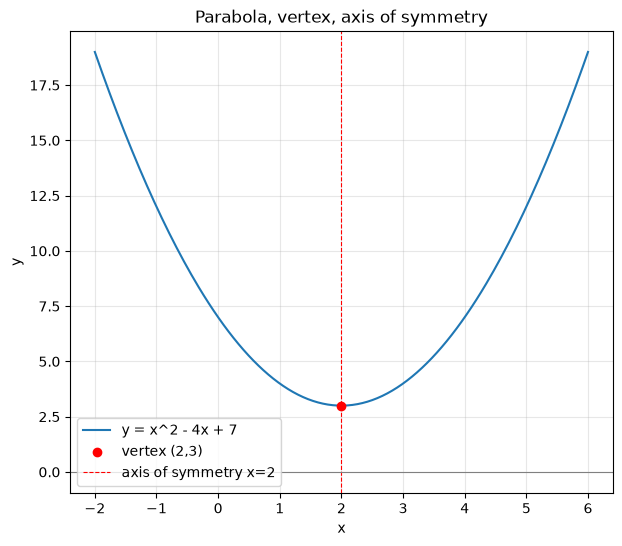

In [4]:
# Plot y = x^2 - 4x + 7 with its vertex and axis of symmetry (Example D / Theorem 5).
a, b, c = 1, -4, 7
h = -b/(2*a)                                  # vertex x-coordinate -b/(2a)
k = c - b**2/(4*a)                            # vertex y-coordinate  c - b^2/(4a)
print(f"vertex = ({h}, {k})  ->  minimum value {k} at x={h}")

xs = np.linspace(h-4, h+4, 200)               # x-values centred on the vertex
ys = a*xs**2 + b*xs + c                        # the parabola values
plt.figure(figsize=(7, 6))
plt.plot(xs, ys, label="y = x^2 - 4x + 7")
plt.scatter([h], [k], color="red", zorder=5, label=f"vertex ({h:.0f},{k:.0f})")
plt.axvline(h, color="red", ls="--", lw=0.8, label="axis of symmetry x=2")
plt.axhline(0, color="gray", lw=0.8)
plt.title("Parabola, vertex, axis of symmetry")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

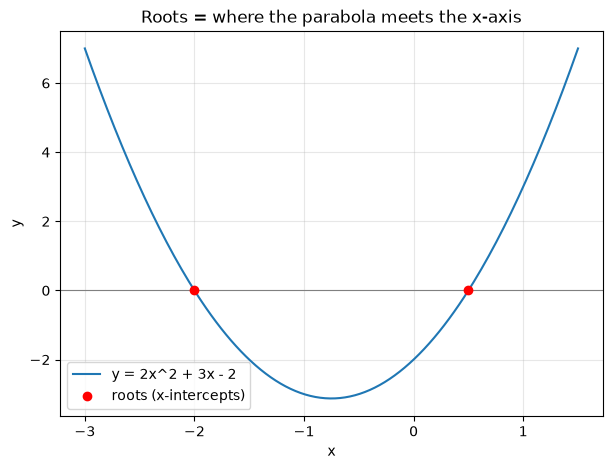

In [5]:
# A parabola that CROSSES the axis twice, to SEE the two real roots (Example A).
a, b, c = 2, 3, -2
xs = np.linspace(-3, 1.5, 200)
ys = a*xs**2 + b*xs + c
roots = np.roots([a, b, c])                   # the two x-intercepts
plt.figure(figsize=(7, 5))
plt.plot(xs, ys, label="y = 2x^2 + 3x - 2")
plt.scatter(roots, [0, 0], color="red", zorder=5, label="roots (x-intercepts)")
plt.axhline(0, color="gray", lw=0.8)
plt.title("Roots = where the parabola meets the x-axis")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 9. The AI hook — gradient descent rolls to the vertex

Theorem 5 says the bowl $y=a(x-h)^2+k$ ($a>0$) has its minimum at the vertex $x=h$. When
the bowl is too complicated to solve by hand, we **roll downhill**: from a guess $x$, step
in the direction that decreases $y$. The downhill direction is the negative of the
**slope** (derivative) $\dfrac{dy}{dx} = 2a(x-h)$. The update rule is
$$ x \leftarrow x - \eta \,\frac{dy}{dx}, $$
where $\eta$ (eta) is a small **learning rate**. This is **gradient descent** — the same
algorithm that trains neural networks, here on the simplest possible bowl.

started at x=-4, ended at x=2.9991  (true vertex h=3.0)
final y = 2.0000  (true minimum k=2.0)


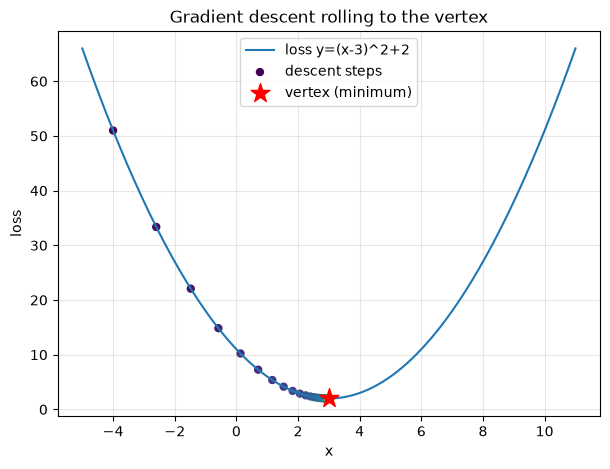

In [6]:
# Gradient descent on the bowl y = (x-3)^2 + 2  (vertex at x=3, min value 2).
a, h, k = 1.0, 3.0, 2.0
f      = lambda x: a*(x - h)**2 + k            # the parabola (the "loss")
fprime = lambda x: 2*a*(x - h)                 # its slope/derivative 2a(x-h)

x_now = -4.0          # a bad starting guess
eta   = 0.1           # learning rate (step size)
path  = [x_now]
for step in range(40):
    x_now = x_now - eta*fprime(x_now)          # step downhill, opposite the slope
    path.append(x_now)

print(f"started at x=-4, ended at x={x_now:.4f}  (true vertex h={h})")
print(f"final y = {f(x_now):.4f}  (true minimum k={k})")

# Show the descent landing in the bowl.
xs = np.linspace(-5, 11, 200)
plt.figure(figsize=(7, 5))
plt.plot(xs, f(xs), label="loss y=(x-3)^2+2")
path = np.array(path)
plt.scatter(path, f(path), c=range(len(path)), cmap="viridis", s=25, label="descent steps")
plt.scatter([h], [k], color="red", marker="*", s=200, zorder=5, label="vertex (minimum)")
plt.title("Gradient descent rolling to the vertex")
plt.xlabel("x"); plt.ylabel("loss"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 10. Exercises (20) — fill these in yourself

Easy → hard, ending in proofs. Try each **before** checking with code.

**A. Factoring & square roots**
1. Solve by factoring: $x^2 - 7x + 12 = 0$.
2. Solve by factoring: $x^2 = 9x$ (careful — do **not** divide by $x$).
3. Solve with the square-root method: $(x+1)^2 = 49$.
4. Solve: $3x^2 - 27 = 0$.

In [7]:
# your work for 1–4


**B. Completing the square & the formula**
5. Complete the square: rewrite $x^2 + 8x + 10$ in the form $(x+p)^2 + q$.
6. Solve by completing the square: $x^2 - 4x - 1 = 0$ (answer with a radical).
7. Solve with the quadratic formula: $3x^2 + 5x - 2 = 0$.
8. Solve with the quadratic formula: $x^2 + 2x - 4 = 0$ (leave the radical exact).

In [8]:
# your work for 5–8


**C. Discriminant & Vieta**
9. Without solving, say how many real roots: (a) $x^2-6x+9$, (b) $2x^2+x+5$, (c) $x^2-3x-1$.
10. Find $k$ so that $x^2 + kx + 9 = 0$ has exactly **one** (repeated) real root.
11. The roots of $x^2 - 8x + 12 = 0$ are $r_1,r_2$. Use **Vieta** (do **not** solve) to
    find $r_1+r_2$, $r_1 r_2$, and then $r_1^2 + r_2^2$. (Hint: $r_1^2+r_2^2=(r_1+r_2)^2-2r_1r_2$.)
12. Build a quadratic equation whose roots are $5$ and $-3$.

In [9]:
# your work for 9–12


**D. Vertex / modeling / optimisation**
13. Find the vertex and the minimum value of $y = x^2 - 10x + 21$. Where are its roots?
14. A ball's height is $h(t) = -5t^2 + 20t$ (metres, seconds). Find the time it hits the
    ground again, and the maximum height (use the vertex).
15. A rectangle has perimeter $40$. Let one side be $x$. Write the area $A(x)$ and find
    the $x$ that **maximises** it (use the vertex). What shape is best?
16. For $y = 2x^2 - 8x + 3$, write it in vertex form $a(x-h)^2+k$.

In [10]:
# your work for 13–16


**E. Proofs (write carefully)**
17. **Derive** the quadratic formula yourself by completing the square on
    $ax^2+bx+c=0$. Justify each step (especially why you divide by $a$ first).
18. **Prove** Vieta's formulas $r_1+r_2=-\tfrac{b}{a}$, $r_1 r_2=\tfrac{c}{a}$ **directly**
    from $x=\dfrac{-b\pm\sqrt\Delta}{2a}$ — i.e. add and multiply the two root expressions.
19. **Prove** that if $a,b,c$ are real and $\Delta = b^2-4ac < 0$, then $ax^2+bx+c$ is
    never $0$ for real $x$, and in fact has the *same sign as $a$* for every real $x$.
    (Hint: use vertex form $a(x-h)^2+k$ and show $k$ has the sign of $a$ when $\Delta<0$.)
20. **Prove** Theorem 5's claim that the parabola is symmetric about $x=h=-\tfrac{b}{2a}$:
    show $f(h+t) = f(h-t)$ for every real $t$, where $f(x)=ax^2+bx+c$.

In [11]:
# your proofs / work for 17–20 (use markdown cells for written proofs)


## 11. Running this notebook with `uv`

From the project root (`C:\dev\math`):

```bash
uv sync                 # install locked dependencies (numpy, sympy, matplotlib, jupyterlab)
uv run jupyter lab      # open notebooks/10-quadratic-equations.ipynb
```

Re-run everything top-to-bottom as a self-test:

```bash
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/10-quadratic-equations.ipynb
```

**Next topic:** *Equations and Inequalities ▸ 3. Complex Numbers; Quadratic Equations in
the Complex Number System* — where the $\Delta<0$ case finally gets solutions.